<a href="https://colab.research.google.com/github/yeshaa23/ZARA-AppsReview-SentimentAnalysis/blob/main/Week%204/Tugas_1A_TF_IDF_Danantara.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tugas 1A - TF-IDF Danantara

## Import Dependencies

In [1]:
import nltk
from nltk.tokenize import sent_tokenize, word_tokenize
nltk.download('punkt')
nltk.download('punkt_tab')

from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt
import pandas as pd
import math
import re

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


## Define Document

In [2]:
sentence = """Jakarta: Badan Pengelola Investasi Daya Anagata Nusantara (BPI Danantara) siap mengawal realisasi investasi yang telah disepakati dengan Qatar. Kesepakatan antara Indonesia dan Qatar merupakan buah dari kunjungan resmi Presiden Prabowo Subianto ke Doha.
Pemerintah Republik Indonesia dan Pemerintah Qatar menggelar diskusi untuk menyepakati kemitraan strategis (co-partnership) dalam pengelolaan dana investasi untuk Indonesia yang akan berfokus di berbagai sektor pembangunan.
Salah satu hasil utama dari kunjungan tersebut adalah untuk membentuk dana investasi bersama senilai USD4 miliar. Dana ini akan difokuskan pada pengembangan berbagai sektor di antaranya termasuk tapi tidak terbatas pada hilirisasi industri, energi terbarukan, dan fasilitas kesehatan di Indonesia.
"Kami menyambut baik kepercayaan yang diberikan oleh Pemerintah Qatar melalui pembentukan dana bersama ini," kata CEO Danantara Indonesia Rosan Perkasa Roeslani dalam keterangan tertulis, Selasa, 15 April 2025.
Presiden Prabowo menyampaikan masing-masing negara akan berkontribusi sebesar USD2 miliar dalam dana tersebut. Dana itu akan dikelola oleh BPI Danantara bersama dengan Qatar Investment Authority (QIA) dalam co-partnership. Buka peluang investasi sektor strategis
Dana tersebut akan difokuskan pada peluang investasi di berbagai sektor strategis, antara lain hilirisasi, kesehatan, energi terbarukan, teknologi, serta sektor-sektor lain yang dipandang relevan oleh pengelola dana.
"Danantara Indonesia siap menjalankan mandat tersebut dengan menerapkan tata kelola investasi yang prudent, transparan, dan berorientasi pada hasil. Fokus kami adalah memastikan bahwa setiap proyek yang didanai memberikan dampak strategis dan berkelanjutan bagi perekonomian nasional," ujar Rosan.
Lebih lanjut, Rosan menegaskan, kolaborasi ini menjadi bukti kepercayaan dunia internasional terhadap kapasitas kelembagaan Indonesia dalam mengelola investasi berskala besar.
"Kemitraan ini merupakan langkah konkret dalam membangun kepercayaan dengan mitra global strategis seperti Qatar. Ini menunjukkan bahwa Indonesia tidak hanya menjadi tujuan investasi, tetapi juga memiliki kapasitas kelembagaan yang mumpuni untuk mengelola nvestasi secara profesional dan akuntabel," ungkapnya.
Inisiatif co-partnership dan perluasan kerja sama strategis ini diharapkan tidak hanya memperkuat hubungan diplomatik kedua negara, tetapi juga memberikan kontribusi nyata terhadap percepatan pembangunan ekonomi dan peningkatan kesejahteraan masyarakat Indonesia."""

## Text Preprocessing

In [3]:
stopword_id = {
    'dan', 'di', 'ke', 'dari', 'yang', 'untuk', 'pada', 'dengan', 'juga', 'atau',
    'ini', 'itu', 'dalam', 'oleh', 'sebagai', 'akan', 'telah', 'lebih', 'bagi',
    'yakni', 'agar', 'saat', 'masih', 'terus', 'melalui', 'serta', 'hingga',
    'karena', 'antara', 'adalah', 'kita', 'dapat', 'maupun', 'sejak', 'lainnya',
    'seluruh', 'tetap', 'lain', 'sangat', 'tahun', 'kata', 'tidak', 'hanya',
    'tersebut', 'masing'
}

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    text = re.sub(r'\bnvestasi\b', 'investasi', text)
    words = text.split()
    words = [w for w in words if w not in stopword_id and len(w) > 2]
    return ' '.join(words)

## Sentence Tokenization

In [4]:
sent_token = sent_tokenize(sentence)
sent_token = [s for s in sent_token if "Google News" not in s and "WhatsApp" not in s and "Jangan lupa" not in s]
print(sent_token)

['Jakarta: Badan Pengelola Investasi Daya Anagata Nusantara (BPI Danantara) siap mengawal realisasi investasi yang telah disepakati dengan Qatar.', 'Kesepakatan antara Indonesia dan Qatar merupakan buah dari kunjungan resmi Presiden Prabowo Subianto ke Doha.', 'Pemerintah Republik Indonesia dan Pemerintah Qatar menggelar diskusi untuk menyepakati kemitraan strategis (co-partnership) dalam pengelolaan dana investasi untuk Indonesia yang akan berfokus di berbagai sektor pembangunan.', 'Salah satu hasil utama dari kunjungan tersebut adalah untuk membentuk dana investasi bersama senilai USD4 miliar.', 'Dana ini akan difokuskan pada pengembangan berbagai sektor di antaranya termasuk tapi tidak terbatas pada hilirisasi industri, energi terbarukan, dan fasilitas kesehatan di Indonesia.', '"Kami menyambut baik kepercayaan yang diberikan oleh Pemerintah Qatar melalui pembentukan dana bersama ini," kata CEO Danantara Indonesia Rosan Perkasa Roeslani dalam keterangan tertulis, Selasa, 15 April 20

In [5]:
# cleaned sentences
cleaned_sentences = [clean_text(sent) for sent in sent_token]
print("\nCleaned sentences (Indonesian stop words removed):")
for clean_sent in cleaned_sentences:
    print(clean_sent)


Cleaned sentences (Indonesian stop words removed):
jakarta badan pengelola investasi daya anagata nusantara bpi danantara siap mengawal realisasi investasi disepakati qatar
kesepakatan indonesia qatar merupakan buah kunjungan resmi presiden prabowo subianto doha
pemerintah republik indonesia pemerintah qatar menggelar diskusi menyepakati kemitraan strategis partnership pengelolaan dana investasi indonesia berfokus berbagai sektor pembangunan
salah satu hasil utama kunjungan membentuk dana investasi bersama senilai usd miliar
dana difokuskan pengembangan berbagai sektor antaranya termasuk tapi terbatas hilirisasi industri energi terbarukan fasilitas kesehatan indonesia
kami menyambut baik kepercayaan diberikan pemerintah qatar pembentukan dana bersama ceo danantara indonesia rosan perkasa roeslani keterangan tertulis selasa april
presiden prabowo menyampaikan negara berkontribusi sebesar usd miliar dana
dana dikelola bpi danantara bersama qatar investment authority qia partnership
buka

## TF-IDF

In [6]:
# training TF-IDF Vectorizer (pakai cleaned sentences)
vectorizer = TfidfVectorizer()
features = vectorizer.fit_transform(cleaned_sentences)

In [7]:
# TF-IDF Feature Matrix
print("\nTF-IDF Feature Matrix (Sparse) on cleaned sentences:")
print(features)

print("\nShape of the Feature Matrix (Number of sentences, Number of unique words after Indonesian stop word removal):")
print(features.shape)

# To see the feature names
feature_names = vectorizer.get_feature_names_out()
print("\nFeature Names (Words in the vocabulary after Indonesian stop word removal):")
print(feature_names)

# To see the TF-IDF values for a specific cleaned sentence (e.g., the first):
if cleaned_sentences:
    first_cleaned_sentence_tfidf = features[0].toarray()
    print("\nTF-IDF values for the first cleaned sentence:")
    print(first_cleaned_sentence_tfidf)

    def get_tfidf_for_sentence(tfidf_matrix, sentence_index, feature_names):
        """Returns a DataFrame of TF-IDF values for a given sentence."""
        sentence_tfidf_values = tfidf_matrix[sentence_index].toarray().flatten()
        tfidf_df = pd.DataFrame({'Feature': feature_names, 'TF-IDF': sentence_tfidf_values})
        tfidf_df = tfidf_df[tfidf_df['TF-IDF'] > 0].sort_values(by='TF-IDF', ascending=False)
        return tfidf_df

    first_cleaned_sentence_tfidf_df = get_tfidf_for_sentence(features, 0, feature_names)
    print("\nTF-IDF values for the first cleaned sentence (sorted):")
    print(first_cleaned_sentence_tfidf_df)
else:
    print("\nNo cleaned sentences to process.")


TF-IDF Feature Matrix (Sparse) on cleaned sentences:
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 221 stored elements and shape (15, 150)>
  Coords	Values
  (0, 50)	0.28494165317784004
  (0, 5)	0.28494165317784004
  (0, 101)	0.24742384462504374
  (0, 48)	0.31333483696461023
  (0, 24)	0.28494165317784004
  (0, 1)	0.28494165317784004
  (0, 94)	0.28494165317784004
  (0, 16)	0.24742384462504374
  (0, 23)	0.20015699583073862
  (0, 132)	0.24742384462504374
  (0, 79)	0.28494165317784004
  (0, 116)	0.28494165317784004
  (0, 32)	0.28494165317784004
  (0, 114)	0.16902311845276635
  (1, 114)	0.20192748514363137
  (1, 61)	0.34041231735378835
  (1, 44)	0.17414630282286622
  (1, 88)	0.29559077578884874
  (1, 17)	0.34041231735378835
  (1, 66)	0.29559077578884874
  (1, 119)	0.34041231735378835
  (1, 110)	0.29559077578884874
  (1, 109)	0.29559077578884874
  (1, 134)	0.34041231735378835
  (1, 34)	0.34041231735378835
  :	:
  (13, 147)	0.2673096697357993
  (14, 44)	0.1115127832651403
  (

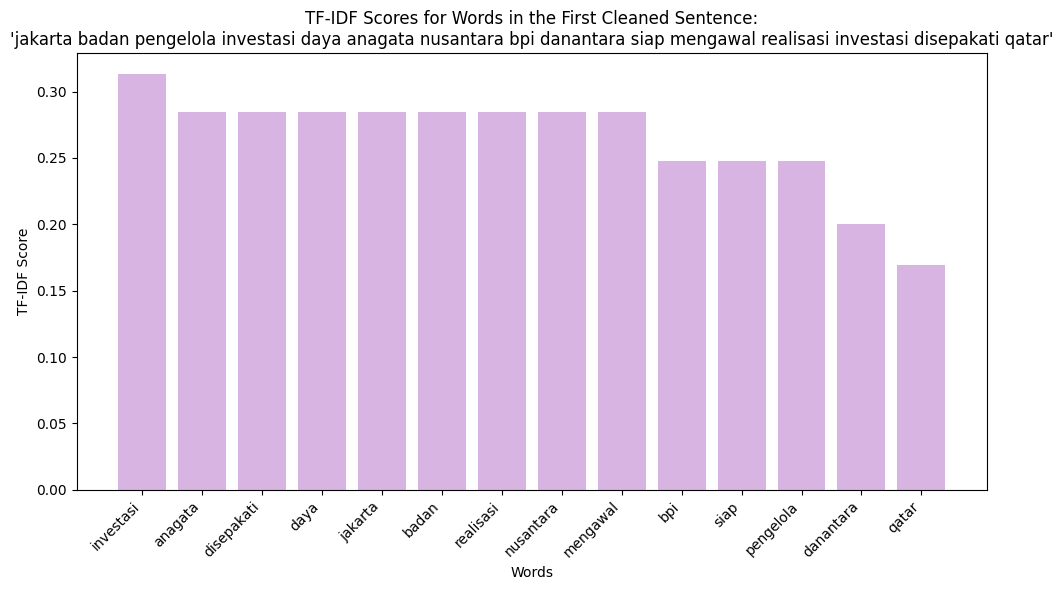

In [8]:
# Get TF-IDF scores for the first cleaned sentence
if cleaned_sentences:
    first_cleaned_sentence = cleaned_sentences[0]
    first_sentence_tfidf_df = get_tfidf_for_sentence(features, 0, feature_names)

    # Visualize the TF-IDF scores as a histogram
    plt.figure(figsize=(10, 6))
    plt.bar(first_sentence_tfidf_df['Feature'], first_sentence_tfidf_df['TF-IDF'], color='#D8B4E2')
    plt.xlabel("Words")
    plt.ylabel("TF-IDF Score")
    plt.title(f"TF-IDF Scores for Words in the First Cleaned Sentence:\n'{first_cleaned_sentence}'")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("No cleaned sentences to visualize.")

## Calculate Sentence Score

**List of Sentences:**
1. Jakarta: Badan Pengelola Investasi Daya Anagata Nusantara (BPI Danantara) siap mengawal realisasi investasi yang telah disepakati dengan Qatar.
2. Kesepakatan antara Indonesia dan Qatar merupakan buah dari kunjungan resmi Presiden Prabowo Subianto ke Doha.
3. Pemerintah Republik Indonesia dan Pemerintah Qatar menggelar diskusi untuk menyepakati kemitraan strategis (co-partnership) dalam pengelolaan dana investasi untuk Indonesia yang akan berfokus di berbagai sektor pembangunan.
4. Salah satu hasil utama dari kunjungan tersebut adalah untuk membentuk dana investasi bersama senilai USD4 miliar.
5. Dana ini akan difokuskan pada pengembangan berbagai sektor di antaranya termasuk tapi tidak terbatas pada hilirisasi industri, energi terbarukan, dan fasilitas kesehatan di Indonesia.
6. "Kami menyambut baik kepercayaan yang diberikan oleh Pemerintah Qatar melalui pembentukan dana bersama ini," kata CEO Danantara Indonesia Rosan Perkasa Roeslani dalam keterangan tertu

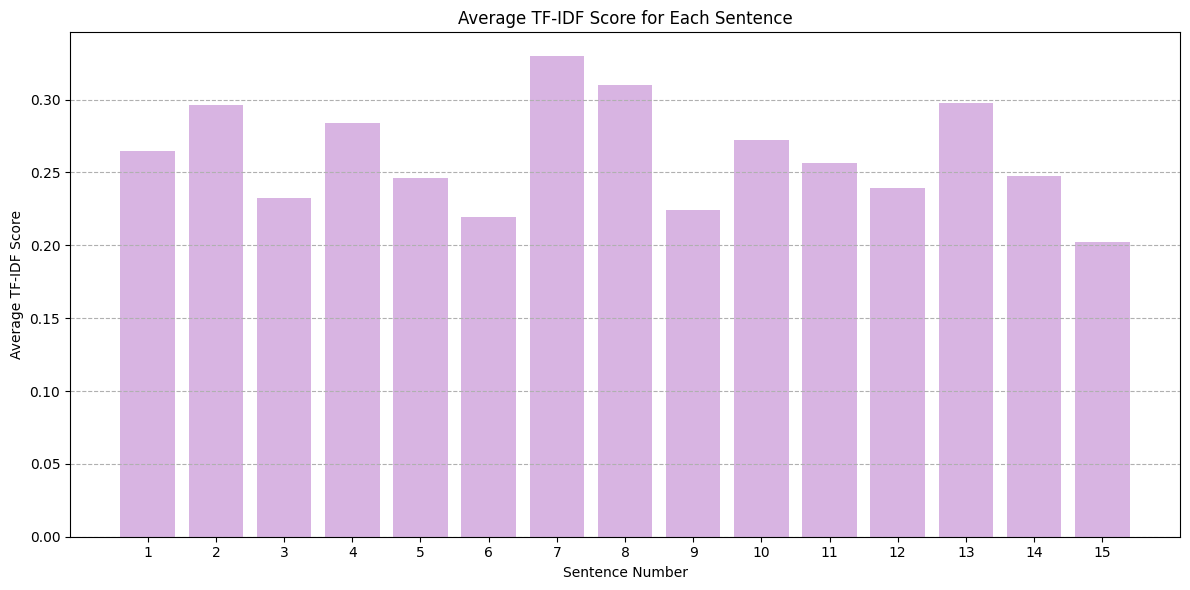


**Explanation of the Histogram :**
Imagine we've given each sentence in the news article a score based on the importance of the words it contains. This score is called the 'Average TF-IDF Score'.

The histogram above is like a bar chart that shows this score for each sentence:
- **The horizontal line (Sentence Number):** Each number on this line represents a different sentence in the article, starting from the first sentence (1) to the last.
- **The vertical bar for each sentence:** The height of each bar shows the 'Average TF-IDF Score' for that particular sentence.

**What does the height of the bar tell us?**
- **Taller bar:** A taller bar means the sentence contains words that are considered more important and unique within the entire article. These sentences likely carry more key information.
- **Shorter bar:** A shorter bar means the sentence contains words that are either less important or more common throughout the article. These sentences might be supporting details or less c

In [9]:
# Variable initialization
sent_index = 0
sent_scores = []

# Calculate sentence TF-IDF score and list sentences
print("**List of Sentences:**")
for i, sent in enumerate(sent_token):
    print(f"{i + 1}. {sent}")
print("\n-------------------------")

# Calculate average TF-IDF score for each sentence
print("\n**Average TF-IDF Score for Each Sentence:**")
for i in features:
    print(f"- Sentence {sent_index + 1}")
    sent_score = i.sum()
    sent_length = len(i.data)
    print("  Sum of TF-IDF scores:", sent_score)
    print("  Number of words:", sent_length)
    avg_score = sent_score / sent_length if sent_length > 0 else 0
    print("  Average TF-IDF score:", avg_score)
    sent_scores.append(avg_score)
    sent_index += 1
print("\n-------------------------")

print("\nList of average TF-IDF scores for each sentence:")
print(sent_scores)

# Visualize the average TF-IDF scores as a histogram
plt.figure(figsize=(12, 6))
plt.bar(range(1, len(sent_scores) + 1), sent_scores, color='#D8B4E2')
plt.xlabel("Sentence Number")
plt.ylabel("Average TF-IDF Score")
plt.title("Average TF-IDF Score for Each Sentence")
plt.xticks(range(1, len(sent_scores) + 1))
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()

# Explanation:
print("\n**Explanation of the Histogram :**")
print("Imagine we've given each sentence in the news article a score based on the importance of the words it contains. This score is called the 'Average TF-IDF Score'.")
print("\nThe histogram above is like a bar chart that shows this score for each sentence:")
print("- **The horizontal line (Sentence Number):** Each number on this line represents a different sentence in the article, starting from the first sentence (1) to the last.")
print("- **The vertical bar for each sentence:** The height of each bar shows the 'Average TF-IDF Score' for that particular sentence.")
print("\n**What does the height of the bar tell us?**")
print("- **Taller bar:** A taller bar means the sentence contains words that are considered more important and unique within the entire article. These sentences likely carry more key information.")
print("- **Shorter bar:** A shorter bar means the sentence contains words that are either less important or more common throughout the article. These sentences might be supporting details or less central to the main topic.")
print("\nSo, by looking at this chart, you can quickly get a sense of which sentences in the article are likely to be the most informative based on the words they use.")

## Define Threshold

In [10]:
# Calculate the average of all sentence scores (threshold)
threshold = sum(sent_scores) / len(sent_scores) if sent_scores else 0

print("Threshold (Average of Sentence Scores):", threshold)

Threshold (Average of Sentence Scores): 0.26148843417134965


## Sentences list for manual TF-IDF checking

In [11]:
sentences = [
    "Jakarta: Badan Pengelola Investasi Daya Anagata Nusantara (BPI Danantara) siap mengawal realisasi investasi yang telah disepakati dengan Qatar.",
    "Kesepakatan antara Indonesia dan Qatar merupakan buah dari kunjungan resmi Presiden Prabowo Subianto ke Doha.",
    "Pemerintah Republik Indonesia dan Pemerintah Qatar menggelar diskusi untuk menyepakati kemitraan strategis (co-partnership) dalam pengelolaan dana investasi untuk Indonesia yang akan berfokus di berbagai sektor pembangunan.",
    "Salah satu hasil utama dari kunjungan tersebut adalah untuk membentuk dana investasi bersama senilai USD4 miliar.",
    "Dana ini akan difokuskan pada pengembangan berbagai sektor di antaranya termasuk tapi tidak terbatas pada hilirisasi industri, energi terbarukan, dan fasilitas kesehatan di Indonesia.",
    '"Kami menyambut baik kepercayaan yang diberikan oleh Pemerintah Qatar melalui pembentukan dana bersama ini," kata CEO Danantara Indonesia Rosan Perkasa Roeslani dalam keterangan tertulis, Selasa, 15 April 2025.',
    "Presiden Prabowo menyampaikan masing-masing negara akan berkontribusi sebesar USD2 miliar dalam dana tersebut.",
    "Dana itu akan dikelola oleh BPI Danantara bersama dengan Qatar Investment Authority (QIA) dalam co-partnership.",
    "Buka peluang investasi sektor strategis\nDana tersebut akan difokuskan pada peluang investasi di berbagai sektor strategis, antara lain hilirisasi, kesehatan, energi terbarukan, teknologi, serta sektor-sektor lain yang dipandang relevan oleh pengelola dana.",
    '"Danantara Indonesia siap menjalankan mandat tersebut dengan menerapkan tata kelola investasi yang prudent, transparan, dan berorientasi pada hasil.',
    'Fokus kami adalah memastikan bahwa setiap proyek yang didanai memberikan dampak strategis dan berkelanjutan bagi perekonomian nasional," ujar Rosan.',
    "Lebih lanjut, Rosan menegaskan, kolaborasi ini menjadi bukti kepercayaan dunia internasional terhadap kapasitas kelembagaan Indonesia dalam mengelola investasi berskala besar.",
    '"Kemitraan ini merupakan langkah konkret dalam membangun kepercayaan dengan mitra global strategis seperti Qatar.',
    'Ini menunjukkan bahwa Indonesia tidak hanya menjadi tujuan investasi, tetapi juga memiliki kapasitas kelembagaan yang mumpuni untuk mengelola nvestasi secara profesional dan akuntabel," ungkapnya.',
    "Inisiatif co-partnership dan perluasan kerja sama strategis ini diharapkan tidak hanya memperkuat hubungan diplomatik kedua negara, tetapi juga memberikan kontribusi nyata terhadap percepatan pembangunan ekonomi dan peningkatan kesejahteraan masyarakat Indonesia."
]

# Initialize a list to store cleaned sentences
all_cleaned_sentences = []
for sentence_item in sentences:
    cleaned_sentence = clean_text(sentence_item)
    all_cleaned_sentences.append(cleaned_sentence)

# Function to calculate TF for a term in a document
def calculate_tf(term, document):
    words = word_tokenize(document.lower())
    return words.count(term) / len(words) if len(words) > 0 else 0

# Function to calculate IDF for a term across all documents
def calculate_idf(term, all_documents):
    num_documents_with_term = sum(1 for doc in all_documents if term.lower() in word_tokenize(doc.lower()))
    if num_documents_with_term > 0:
        return math.log(len(all_documents) / num_documents_with_term)
    else:
        return 0

# Calculate TF-IDF for "investasi" in each sentence
tfidf_scores = {}
for i, sentence_item in enumerate(sentences):
    cleaned_sentence = clean_text(sentence_item)
    tf = calculate_tf("investasi", cleaned_sentence)
    idf = calculate_idf("investasi", all_cleaned_sentences)
    tfidf = tf * idf
    tfidf_scores[f"Sentence {i+1}"] = tfidf

# Print the TF-IDF scores for "investasi" in each sentence
print("TF-IDF Score for 'investasi' in each cleaned sentence:")
for sentence_num, score in tfidf_scores.items():
    print(f"{sentence_num}: {score:.4f}")

# Calculate the overall IDF for "investasi" across all cleaned sentences
overall_idf_investasi = calculate_idf("investasi", all_cleaned_sentences)
print(f"\nOverall IDF for 'investasi': {overall_idf_investasi:.4f}")

TF-IDF Score for 'investasi' in each cleaned sentence:
Sentence 1: 0.1016
Sentence 2: 0.0000
Sentence 3: 0.0401
Sentence 4: 0.0635
Sentence 5: 0.0000
Sentence 6: 0.0000
Sentence 7: 0.0000
Sentence 8: 0.0000
Sentence 9: 0.0663
Sentence 10: 0.0586
Sentence 11: 0.0000
Sentence 12: 0.0448
Sentence 13: 0.0000
Sentence 14: 0.0897
Sentence 15: 0.0000

Overall IDF for 'investasi': 0.7621


## Get Sentences

In [12]:
print("Threshold (Average of Sentence Scores):", threshold)

# Final summary initialization
final_summ = ""

# Get summary sentences
print("\n**Summary Sentences (above or equal to the threshold):**")
for index, data in enumerate(sent_scores):
    if data >= threshold:
        final_summ = final_summ + " " + sent_token[index]
        print(f"- {sent_token[index]}")

print("\n**Final Summary:**")
print(final_summ.strip())

Threshold (Average of Sentence Scores): 0.26148843417134965

**Summary Sentences (above or equal to the threshold):**
- Jakarta: Badan Pengelola Investasi Daya Anagata Nusantara (BPI Danantara) siap mengawal realisasi investasi yang telah disepakati dengan Qatar.
- Kesepakatan antara Indonesia dan Qatar merupakan buah dari kunjungan resmi Presiden Prabowo Subianto ke Doha.
- Salah satu hasil utama dari kunjungan tersebut adalah untuk membentuk dana investasi bersama senilai USD4 miliar.
- Presiden Prabowo menyampaikan masing-masing negara akan berkontribusi sebesar USD2 miliar dalam dana tersebut.
- Dana itu akan dikelola oleh BPI Danantara bersama dengan Qatar Investment Authority (QIA) dalam co-partnership.
- "Danantara Indonesia siap menjalankan mandat tersebut dengan menerapkan tata kelola investasi yang prudent, transparan, dan berorientasi pada hasil.
- "Kemitraan ini merupakan langkah konkret dalam membangun kepercayaan dengan mitra global strategis seperti Qatar.

**Final Summa

## TF-IDF "investasi" using TfidfVectorizer

In [13]:
sentences = [
    "Jakarta: Badan Pengelola Investasi Daya Anagata Nusantara (BPI Danantara) siap mengawal realisasi investasi yang telah disepakati dengan Qatar.",
    "Kesepakatan antara Indonesia dan Qatar merupakan buah dari kunjungan resmi Presiden Prabowo Subianto ke Doha.",
    "Pemerintah Republik Indonesia dan Pemerintah Qatar menggelar diskusi untuk menyepakati kemitraan strategis (co-partnership) dalam pengelolaan dana investasi untuk Indonesia yang akan berfokus di berbagai sektor pembangunan.",
    "Salah satu hasil utama dari kunjungan tersebut adalah untuk membentuk dana investasi bersama senilai USD4 miliar.",
    "Dana ini akan difokuskan pada pengembangan berbagai sektor di antaranya termasuk tapi tidak terbatas pada hilirisasi industri, energi terbarukan, dan fasilitas kesehatan di Indonesia.",
    '"Kami menyambut baik kepercayaan yang diberikan oleh Pemerintah Qatar melalui pembentukan dana bersama ini," kata CEO Danantara Indonesia Rosan Perkasa Roeslani dalam keterangan tertulis, Selasa, 15 April 2025.',
    "Presiden Prabowo menyampaikan masing-masing negara akan berkontribusi sebesar USD2 miliar dalam dana tersebut.",
    "Dana itu akan dikelola oleh BPI Danantara bersama dengan Qatar Investment Authority (QIA) dalam co-partnership.",
    "Buka peluang investasi sektor strategis.",
    "Dana tersebut akan difokuskan pada peluang investasi di berbagai sektor strategis, antara lain hilirisasi, kesehatan, energi terbarukan, teknologi, serta sektor-sektor lain yang dipandang relevan oleh pengelola dana.",
    '"Danantara Indonesia siap menjalankan mandat tersebut dengan menerapkan tata kelola investasi yang prudent, transparan, dan berorientasi pada hasil.',
    'Fokus kami adalah memastikan bahwa setiap proyek yang didanai memberikan dampak strategis dan berkelanjutan bagi perekonomian nasional," ujar Rosan.',
    "Lebih lanjut, Rosan menegaskan, kolaborasi ini menjadi bukti kepercayaan dunia internasional terhadap kapasitas kelembagaan Indonesia dalam mengelola investasi berskala besar.",
    '"Kemitraan ini merupakan langkah konkret dalam membangun kepercayaan dengan mitra global strategis seperti Qatar.',
    'Ini menunjukkan bahwa Indonesia tidak hanya menjadi tujuan investasi, tetapi juga memiliki kapasitas kelembagaan yang mumpuni untuk mengelola investasi secara profesional dan akuntabel," ungkapnya.',
    "Inisiatif co-partnership dan perluasan kerja sama strategis ini diharapkan tidak hanya memperkuat hubungan diplomatik kedua negara, tetapi juga memberikan kontribusi nyata terhadap percepatan pembangunan ekonomi dan peningkatan kesejahteraan masyarakat Indonesia."
]

# Function to calculate TF for a term in a document
def calculate_tf(term, document):
    words = word_tokenize(document.lower())
    return words.count(term) / len(words) if len(words) > 0 else 0

# Function to calculate IDF for a term across all documents
def calculate_idf(term, all_documents):
    num_documents_with_term = sum(1 for doc in all_documents if term.lower() in word_tokenize(doc.lower()))
    if num_documents_with_term > 0:
        return math.log(len(all_documents) / num_documents_with_term)
    else:
        return 0

# Calculate TF-IDF for "investasi" in each sentence
tfidf_scores = {}
all_cleaned_sentences = []

for i, sentence_item in enumerate(sentences):
    cleaned_sentence = clean_text(sentence_item)
    all_cleaned_sentences.append(cleaned_sentence)
    tf = calculate_tf("investasi", cleaned_sentence)
    idf = calculate_idf("investasi", all_cleaned_sentences)
    tfidf = tf * idf
    tfidf_scores[f"Sentence {i+1}"] = tfidf

# Print the TF-IDF scores for "investasi" in each sentence
print("TF-IDF Score for 'investasi' in each sentence:")
for sentence_num, score in tfidf_scores.items():
    print(f"{sentence_num}: {score:.4f}")

# Calculate the overall IDF for "investasi" across all cleaned sentences
overall_idf_investasi = calculate_idf("investasi", all_cleaned_sentences)
print(f"\nOverall IDF for 'investasi': {overall_idf_investasi:.4f}")

# Use scikit-learn's TfidfVectorizer
vectorizer_check = TfidfVectorizer(stop_words=list(stopword_id))
tfidf_matrix = vectorizer_check.fit_transform(sentences)
feature_names = vectorizer_check.get_feature_names_out()

try:
    investasi_index = list(feature_names).index("investasi")
    print("\nTF-IDF Score for 'investasi' using TfidfVectorizer:")
    for i, sentence_item in enumerate(sentences):
        tfidf = tfidf_matrix[i, investasi_index]
        print(f"Sentence {i+1}: {tfidf:.4f}")
except ValueError:
    print("\n'investasi' not found in the vocabulary after stop word removal by TfidfVectorizer.")

TF-IDF Score for 'investasi' in each sentence:
Sentence 1: 0.0000
Sentence 2: 0.0000
Sentence 3: 0.0213
Sentence 4: 0.0240
Sentence 5: 0.0000
Sentence 6: 0.0000
Sentence 7: 0.0000
Sentence 8: 0.0000
Sentence 9: 0.1622
Sentence 10: 0.0385
Sentence 11: 0.0466
Sentence 12: 0.0000
Sentence 13: 0.0364
Sentence 14: 0.0000
Sentence 15: 0.0740
Sentence 16: 0.0000

Overall IDF for 'investasi': 0.6931

TF-IDF Score for 'investasi' using TfidfVectorizer:
Sentence 1: 0.2980
Sentence 2: 0.0000
Sentence 3: 0.1333
Sentence 4: 0.1693
Sentence 5: 0.0000
Sentence 6: 0.0000
Sentence 7: 0.0000
Sentence 8: 0.0000
Sentence 9: 0.3063
Sentence 10: 0.1332
Sentence 11: 0.1603
Sentence 12: 0.0000
Sentence 13: 0.1415
Sentence 14: 0.0000
Sentence 15: 0.2794
Sentence 16: 0.0000


In [14]:
final_summ

' Jakarta: Badan Pengelola Investasi Daya Anagata Nusantara (BPI Danantara) siap mengawal realisasi investasi yang telah disepakati dengan Qatar. Kesepakatan antara Indonesia dan Qatar merupakan buah dari kunjungan resmi Presiden Prabowo Subianto ke Doha. Salah satu hasil utama dari kunjungan tersebut adalah untuk membentuk dana investasi bersama senilai USD4 miliar. Presiden Prabowo menyampaikan masing-masing negara akan berkontribusi sebesar USD2 miliar dalam dana tersebut. Dana itu akan dikelola oleh BPI Danantara bersama dengan Qatar Investment Authority (QIA) dalam co-partnership. "Danantara Indonesia siap menjalankan mandat tersebut dengan menerapkan tata kelola investasi yang prudent, transparan, dan berorientasi pada hasil. "Kemitraan ini merupakan langkah konkret dalam membangun kepercayaan dengan mitra global strategis seperti Qatar.'

## Summarization Result

In [15]:
# Final summary initialization
final_summ = ""

# Get summary sentences
for index, data in enumerate(sent_scores):
    if data >= threshold:
        final_summ = final_summ + " " + sent_token[index]
        print("- ", sent_token[index])

-  Jakarta: Badan Pengelola Investasi Daya Anagata Nusantara (BPI Danantara) siap mengawal realisasi investasi yang telah disepakati dengan Qatar.
-  Kesepakatan antara Indonesia dan Qatar merupakan buah dari kunjungan resmi Presiden Prabowo Subianto ke Doha.
-  Salah satu hasil utama dari kunjungan tersebut adalah untuk membentuk dana investasi bersama senilai USD4 miliar.
-  Presiden Prabowo menyampaikan masing-masing negara akan berkontribusi sebesar USD2 miliar dalam dana tersebut.
-  Dana itu akan dikelola oleh BPI Danantara bersama dengan Qatar Investment Authority (QIA) dalam co-partnership.
-  "Danantara Indonesia siap menjalankan mandat tersebut dengan menerapkan tata kelola investasi yang prudent, transparan, dan berorientasi pada hasil.
-  "Kemitraan ini merupakan langkah konkret dalam membangun kepercayaan dengan mitra global strategis seperti Qatar.


In [16]:
final_summ

' Jakarta: Badan Pengelola Investasi Daya Anagata Nusantara (BPI Danantara) siap mengawal realisasi investasi yang telah disepakati dengan Qatar. Kesepakatan antara Indonesia dan Qatar merupakan buah dari kunjungan resmi Presiden Prabowo Subianto ke Doha. Salah satu hasil utama dari kunjungan tersebut adalah untuk membentuk dana investasi bersama senilai USD4 miliar. Presiden Prabowo menyampaikan masing-masing negara akan berkontribusi sebesar USD2 miliar dalam dana tersebut. Dana itu akan dikelola oleh BPI Danantara bersama dengan Qatar Investment Authority (QIA) dalam co-partnership. "Danantara Indonesia siap menjalankan mandat tersebut dengan menerapkan tata kelola investasi yang prudent, transparan, dan berorientasi pada hasil. "Kemitraan ini merupakan langkah konkret dalam membangun kepercayaan dengan mitra global strategis seperti Qatar.'